# АНАЛИЗ ЭФФЕКТИВНОСТИ ВАРИАНТОВ ПОСАДОЧНОЙ СТРАНИЦЫ

Цель: проанализировать эффективность двух вариантов посадочной страницы сразу по двум критериям — конверсии покупки и ежедневному среднему чеку.

Компания предлагает следующие варианты туров:

Таиланд — 100 000 рублей;  
Турция — 60 000 рублей;  
Мальдивы — 200 000 рублей;  
Санкт-Петербург — 10 000 рублей;  
Камчатка — 150 000 рублей.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.stats import ttest_ind, shapiro
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

Считывание данных:

In [2]:
data = pd.read_csv('data/ab_data_tourist.csv')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


Данные представлены следующими полями:

**user_id** — идентификатор пользователя, зашедшего на сайт;  
**data** — дата посещения сайта;  
**group** — группа теста (контрольная — А или тестовая — B);  
**purchase** — признак покупки: совершил ли пользователь покупку тура (1 — да, 0 — нет);  
**price** — цена купленного тура (если покупка не состоялась, цена равна 0).

## Анализ структуры данных и их предобработка

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB


Пропуски в данных отсутствуют.  
Необходимо преобразование столбца date в тип данных datetime.

In [4]:
# Приведение к типу datetime
data.date = pd.to_datetime(data.date, format='%Y-%m-%d')

In [5]:
# Определение длительности проведения A/B-тестирования в каждой группе
data.groupby('group')['date'].agg(['min', 'max'])

,min,max
group,,
A,2021-01-02,2021-01-24
B,2021-01-02,2021-01-24


Время начала и окончания тестирования обеих групп совпадает, по данному параметру очистка не требуется.

In [6]:
# Проверка наличия пользователей, попавших в обе группы тестирования
data_a = set(data[data['group']=='A']['user_id'])
data_b = set(data[data['group']=='B']['user_id'])
users_intersection = data_a.intersection(data_b)
len(users_intersection)

1895

Имеется 1895 пользователей, попавших в обе группы тестирования, требуется исключение записей данных пользователей из данных тестирования.

In [7]:
data = data[data['user_id'].apply(lambda x: x not in users_intersection)]
data.reset_index(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290688 entries, 0 to 290687
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   index     290688 non-null  int64         
 1   user_id   290688 non-null  int64         
 2   date      290688 non-null  datetime64[ns]
 3   group     290688 non-null  object        
 4   purchase  290688 non-null  int64         
 5   price     290688 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 13.3+ MB


В результате анализа структуры данных и их первичной обработки и очистки датасет содержит 290688 записей.

## Первичный анализ результатов A/B-тестирования

Рассчет вспомогательных показателей для контрольной и тестовой групп:

- количество посещений сайта (visits);  
- суммарное количество совершённых покупок (sum_purchase);  
- сумма всех покупок (sum_price). 

In [8]:
data_group = data.groupby(['group']).agg({'user_id':'count',
                                          'purchase':'sum',
                                          'price': 'sum'}).reset_index().rename(columns={'user_id': 'visits',
                                                                                         'purchase':'sum_purchase',
                                                                                         'price':'sum_price'})
data_group

,group,visits,sum_purchase,sum_price
0,A,145307,17487,1417780000
1,B,145381,17290,1533010000


Количество посещений обоих вариантов посадочной страницы различается несущественно, что свидетельствует о сбалансированности выборки.

Рассчет ключевых показателей для каждой из групп и добавление результатов в таблицу data_group:
- конверсия (conversion);
- средний чек (mean_check).

In [9]:
data_group['conversion'] = round(data_group['sum_purchase'] / data_group['visits'] * 100, 2)
data_group['mean_check'] = round(data_group['sum_price'] / data_group['sum_purchase'], 2)
data_group

,group,visits,sum_purchase,sum_price,conversion,mean_check
0,A,145307,17487,1417780000,12.03,81076.23
1,B,145381,17290,1533010000,11.89,88664.55


Конверсия варианта А выше (12.03%), при этом показатель среднего чека ниже (81076 руб.).  
При этом сумма покупок варианта В также выше (1533 млн. руб.)

Сравнение вариантов A/B по покупательской способности каждого из туров.

In [10]:
pt = data[data['purchase'] == 1].pivot_table(values='user_id',
                                             index='group',
                                             columns='price',
                                             aggfunc='count')
pt

price,10000,60000,100000,150000,200000
group,,,,,
A,5182,5271,1832,3478,1724
B,5201,1730,5227,3438,1694


In [11]:
# Построение тепловой карты
fig = go.Figure(data=go.Heatmap(x=list(map(str, pt.columns.to_list())),
                                y=pt.index[::-1],
                                z=pt.values[::-1],
                                colorscale='Greens',
                                colorbar_title = 'Количество туров',
                                text=pt.values[::-1].astype(str),
                                texttemplate="%{text}"))
# Заголовк и подписи
fig.update_layout(title='Покупательская способность туров',
                  title_x=0.5, # Выравнивание заголовка посередине
                  yaxis_title='Вариант посадочной страницы', # Подпись Y
                  xaxis_title='Стоимость тура, руб.') # Подпись Х
fig.show()

- Покупательская способность следующих направлений условно равна для обоих вариантов:
    - *Санкт-Петербург* (10000),
    - *Камчатка* (150000),
    - *Мальдивы* (200000);
- Покупательская способность в группе A выше в направлении *Турция* (60000);
- Покупательская способность в группе B выше в направлении *Тайланд* (100000).

## Анализ данных на предмет стабилизации метрик

Группировка данных по дате и группе тестирования и построение таблицы с ежедневными данными результатов проведения A/B-тестирования:
- количество посещений страницы;
- количество покупок;
- сумму покупок.

In [12]:
daily_data = data.groupby(['date', 'group']).agg({'user_id':'count',
                                                  'purchase':'sum',
                                                  'price':'sum'}).reset_index().rename(columns={'user_id':'count_visits',
                                                                                                'purchase':'count_purchase',
                                                                                                'price':'sum_price'})
daily_data.head()

,date,group,count_visits,count_purchase,sum_price
0,2021-01-02,A,2854,359,29410000
1,2021-01-02,B,2861,345,29660000
2,2021-01-03,A,6596,748,62000000
3,2021-01-03,B,6619,754,65960000
4,2021-01-04,A,6566,799,64250000


Рассчет ежедневной конверсии (ежедневное количество покупок / ежедневное количество посещений) в группах и ежедневного среднего чека (ежедневная сумма покупок / ежедневное количество покупок).

In [13]:
daily_data['conversion'] = round(daily_data['count_purchase'] / daily_data['count_visits'] * 100, 2)
daily_data['mean_check'] = round(daily_data['sum_price'] / daily_data['count_purchase'], 2)
daily_data.head()

,date,group,count_visits,count_purchase,sum_price,conversion,mean_check
0,2021-01-02,A,2854,359,29410000,12.58,81922.01
1,2021-01-02,B,2861,345,29660000,12.06,85971.01
2,2021-01-03,A,6596,748,62000000,11.34,82887.70
3,2021-01-03,B,6619,754,65960000,11.39,87480.11
4,2021-01-04,A,6566,799,64250000,12.17,80413.02


Рассчет кумулятивных показателей:
- кумулятивное количество посещений страницы;
- кумулятивное количество покупок;
- кумулятивную сумму покупок.

In [14]:
daily_data['cum_count_visits'] = daily_data.groupby(['group'])['count_visits'].cumsum()
daily_data['cum_count_purchase'] = daily_data.groupby(['group'])['count_purchase'].cumsum()
daily_data['cum_sum_price'] = daily_data.groupby(['group'])['sum_price'].cumsum()
daily_data.head()

,date,group,count_visits,count_purchase,sum_price,conversion,mean_check,cum_count_visits,cum_count_purchase,cum_sum_price
0,2021-01-02,A,2854,359,29410000,12.58,81922.01,2854,359,29410000
1,2021-01-02,B,2861,345,29660000,12.06,85971.01,2861,345,29660000
2,2021-01-03,A,6596,748,62000000,11.34,82887.70,9450,1107,91410000
3,2021-01-03,B,6619,754,65960000,11.39,87480.11,9480,1099,95620000
4,2021-01-04,A,6566,799,64250000,12.17,80413.02,16016,1906,155660000


Вычисление кумулятивной конверсии и кумулятивного среднего чека на основе полученных кумулятивных показателей.

In [15]:
daily_data['cum_conversion'] = round(daily_data['cum_count_purchase'] / daily_data['cum_count_visits'] * 100, 2)
daily_data['cum_mean_check'] = round(daily_data['cum_sum_price'] / daily_data['cum_count_purchase'], 2)
daily_data.head()

,date,group,count_visits,count_purchase,sum_price,conversion,mean_check,cum_count_visits,cum_count_purchase,cum_sum_price,cum_conversion,cum_mean_check
0,2021-01-02,A,2854,359,29410000,12.58,81922.01,2854,359,29410000,12.58,81922.01
1,2021-01-02,B,2861,345,29660000,12.06,85971.01,2861,345,29660000,12.06,85971.01
2,2021-01-03,A,6596,748,62000000,11.34,82887.70,9450,1107,91410000,11.71,82574.53
3,2021-01-03,B,6619,754,65960000,11.39,87480.11,9480,1099,95620000,11.59,87006.37
4,2021-01-04,A,6566,799,64250000,12.17,80413.02,16016,1906,155660000,11.90,81668.42


Построение графиков кумулятивных конверсии и среднего чека каждой группы по дням.

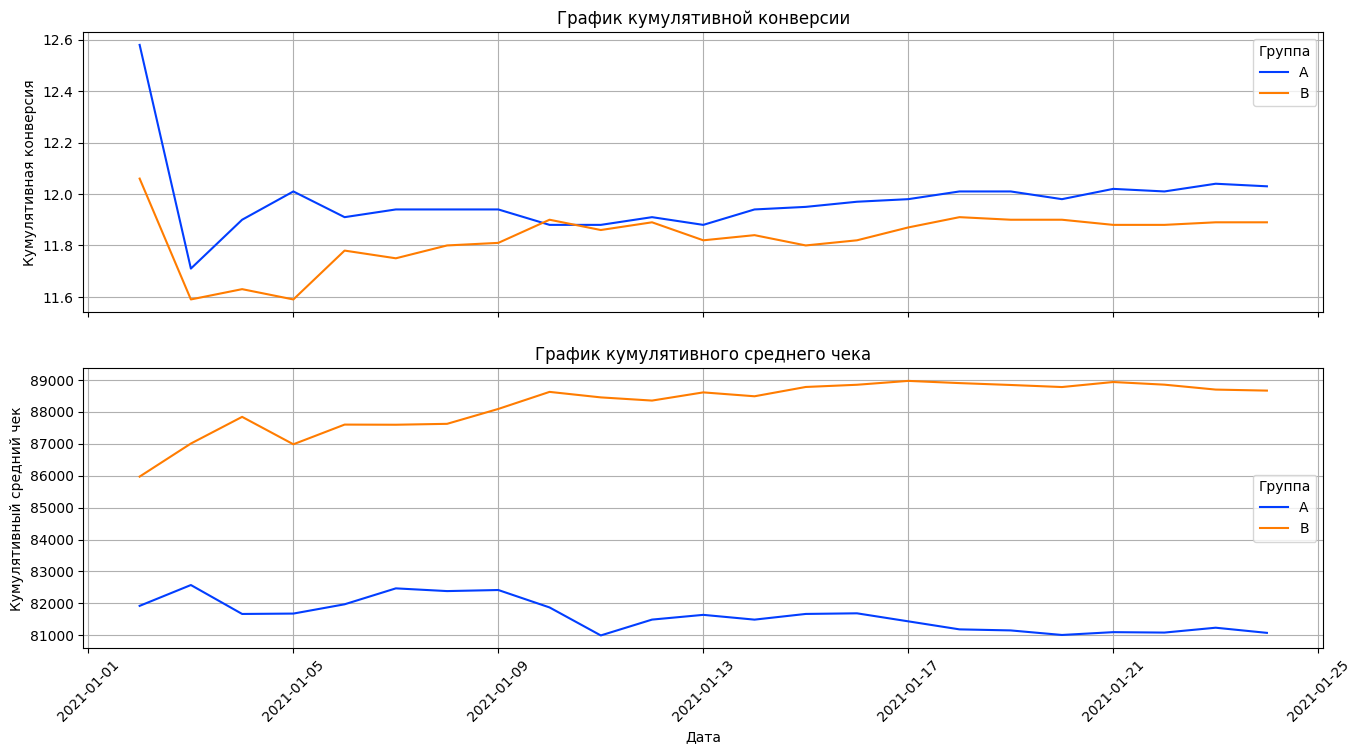

In [16]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 8), sharex='row')
# Построение графика
sns.lineplot(data=daily_data,
             x='date',
             y='cum_conversion',
             hue='group',
             ax=ax[0],
             palette='bright')
sns.lineplot(data=daily_data,
             x='date',
             y='cum_mean_check',
             hue='group',
             ax=ax[1],
             palette='bright')
# Подписи осей, заголовка графика и легенды
ax[0].legend(title='Группа')
ax[0].set(xticklabels=[], xlabel='', ylabel='Кумулятивная конверсия', title='График кумулятивной конверсии')
ax[0].grid(True)
ax[1].legend(title='Группа', loc='center right')
ax[1].set(xlabel='Дата', ylabel='Кумулятивный средний чек' , title='График кумулятивного среднего чека')
ax[1].grid(True);
ax[1].xaxis.set_tick_params(rotation=45);

Исходя из графиков, до 2021-01-11 кумулятивные метрики нестабильны, ориентировочно после 2021-01-13 резкое изменение значений прекращается.  
Судя по графику кумулятивной конверсии, конверсия группы B стабильно ниже конверсии группы A на всем промежутке времени.  
По графику кумулятивного среднего чека видно, что средний чек в группе A меньше среднего чека в группе B.
На основании стабилизированного кумулятивного графика можно сделать вывод, что длительность эксперимента была достаточной для того, чтобы судить о статистической значимости разности между показателем конверсии в группах. Необходимо проведение статистических тестов для подтверждения разницы полученных данных.

## Статистический анализ результатов A/B-тестирования

Для определения наличия статистической разницы между конверсиями в группах А и B проведем тестирование при следующих нулевой и альтернативной гипотезах:  
$H_0$: Конверсии в группах А и B равны;  
$H_1$: Конверсия в группе А больше чем конверсия в группе B.  

Для определения статистической разницы применим z-тест, так как сравниваются конверсии (пропорции) по двум выборкам и число наблюдений достаточно велико.

Но прежде проверим данные на нормальность, для этого применим критерий Шапиро — Уилка. Проверим следующие гипотезы:  
$H_0$: Распределение выборки нормальное;  
$H_1$: Распределение выборки отлично от нормального.  

Уровень значимости для проведения статистических тестов устанавливаем $\alpha$=0.05.

In [17]:
# Проверка данных на нормальность
# Уровень значимости
alpha = 0.05
# Вычисляем результат теста Шапиро — Уилка
shapiro_result = shapiro(daily_data['conversion'])
# Сравниваем полученное p-value с уровнем значимости
if shapiro_result.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной: распределение отлично от нормального")
else:
    print("Принимаем нулевую гипотезу: распределение нормальное")

Принимаем нулевую гипотезу: распределение нормальное


In [18]:
# Группировка таблицы data по признаку группы и рассчет количества «успехов»
# и общего количества наблюдений для каждой группы
conversion_piv= data.groupby(by=['group'])['purchase'].agg(['sum', 'count'])
conversion_piv

,sum,count
group,,
A,17487,145307
B,17290,145381


In [19]:
# Статистический анализ A/B тестирования
# Вычисляем значение P-value для z-теста для пропорций
_, p_value = proportions_ztest(count=conversion_piv['sum'],  # число "успехов"
                               nobs=conversion_piv['count'], # общее число наблюдений
                               alternative='larger') # правосторонняя альтернативная гипотеза
# Сравниваем полученное p-value с уровнем значимости
if (p_value < alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной: конверсия в группе А выше, чем в группе B")
else:
    print("Принимаем нулевую гипотезу: конверсии в группах равны")

Принимаем нулевую гипотезу: конверсии в группах равны


Результаты проведения статистических тестов указывают на нормальное распределение данных и равенство конверсии в группах A и B.  

Проверим гипотезу о нормальности распределения ежедневного среднего чека в каждой из групп тестирования с использованием критерия Шапиро — Уилка.

In [20]:
# Разделение данных по группам
daily_data_a = daily_data[daily_data['group'] == 'A']
daily_data_b = daily_data[daily_data['group'] == 'B']
# Проверка на нормальность
# Вычисляем результат теста Шапиро — Уилка
shapiro_result_a = shapiro(daily_data_a['mean_check'])
shapiro_result_b = shapiro(daily_data_b['mean_check'])
# Сравниваем полученное p-value с уровнем значимости
if shapiro_result_a.pvalue > alpha:
    print('Для группы A: распределение нормальное')
else:
    print('Для группы A: распределение отлично от нормального')
if shapiro_result_b.pvalue > alpha:
    print('Для группы B: распределение нормальное')
else:
    print('Для группы B: распределение отлично от нормального')

Для группы A: распределение нормальное
Для группы B: распределение нормальное


Результат проведения статистического теста указывает на нормальное распределение данных в группах.  

Для определения наличия статистической разницы между ежедневными средними чеками в группах А и B проведем тестирование при следующих нулевой и альтернативной гипотезе:  
$H_0$: Ежедневные средние чеки в группах А и B равны;  
$H_1$: Ежедневный средний чек в группе А меньше чем в группе B.  

Для опеределения статистической разницы применим t-тест, так как распределение признака нормальное, cравниваются только две группы и количество объектов в выборке не больше 30.

In [21]:
# Вычисление результата t-теста для выборок
result = ttest_ind(daily_data_a['mean_check'],
                   daily_data_b['mean_check'],
                   alternative='less')
# Сравниваем полученное p-value с уровнем значимости
if result.pvalue < alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной: ежедневный средний чек в группе А меньше, чем в группе B")
else:
    print("Принимаем нулевую гипотезу: ежедневные средние чеки в группах равны")

Отвергаем нулевую гипотезу в пользу альтернативной: ежедневный средний чек в группе А меньше, чем в группе B


Результаты проведения статистических тестов указывают на нормальное распределение данных и повышенный ежедневный средний чек в группе В.  

Для подтверждения результатов статистических тестов построим 95% доверительные интервалы для конверсий в каждой из групп, разницы конверсий в группах и ежедневного среднего чека в каждой из них.

In [22]:
def proportions_conf_interval(n, X_p, gamma=0.95):
    ''' Функция для расчета 95 % доверительного интервала 
        для конверсий в каждой из групп '''
    # Уровень значимости
    alpha = 1 - gamma
    # z-критическое
    z_crit = -stats.norm.ppf(alpha / 2)
    # Погрешность
    eps = z_crit * (X_p * (1 - X_p) / n) ** 0.5
    # Левая (нижняя) граница
    lower_bound = X_p - eps
    # Правая (верхняя) граница
    upper_bound = X_p + eps
    # Возвращаем кортеж из округлённых границ интервала
    return round(lower_bound * 100, 2), round(upper_bound * 100, 2)


def diff_proportions_conf_interval(n, X_p, gamma=0.95):
    ''' Функция для расчета 95 % доверительного интервала 
        для разницы конверсий в группах '''
    # Уровень значимости
    alpha = 1 - gamma
    # Выборочная разница конверсий групп B и A
    diff = X_p[1] - X_p[0]
    # z-критическое
    z_crit = -stats.norm.ppf(alpha / 2)
    # Погрешность
    eps = z_crit * (X_p[0] * (1 - X_p[0]) / n[0] + X_p[1] * (1 - X_p[1]) / n[1]) ** 0.5
    # Левая (нижняя) граница
    lower_bound = diff - eps
    # Правая (верхняя) граница
    upper_bound = diff + eps
    # Возвращаем кортеж из округлённых границ интервала
    return round(lower_bound *100, 2), round(upper_bound * 100, 2)


def t_crit_conf_interval(n, X_mean, X_std, gamma=0.95):
    ''' Функция для расчета 95 % доверительного интервала 
        для ежедневного среднего чека в каждой из групп '''
    # Уровень значимости
    alpha = 1 - gamma
    # Число степеней свободы
    k = n - 1
    # t-критическое
    t_crit = -stats.t.ppf(alpha / 2, k)
    # Погрешность
    eps = t_crit * X_std / (n ** 0.5)
    # Левая (нижняя) граница
    lower_bound = X_mean - eps
    # Правая (верхняя) граница
    upper_bound = X_mean + eps
    # Возвращаем кортеж из округлённых границ интервала
    return (round(lower_bound), round(upper_bound))

In [23]:
# Данные группы А
data_a = data[data['group'] == 'A'].copy()
# Данные группы B
data_b = data[data['group'] == 'B'].copy()
# Расчёт двусторонних доверительных интервалов конверсии по группам
conf_interval_a = proportions_conf_interval(n = data_a['user_id'].count(),    # размер выборки
                                            X_p = data_a['purchase'].mean())  # выборочная пропорция
conf_interval_b = proportions_conf_interval(n = data_b['user_id'].count(),    # размер выборки
                                            X_p = data_b['purchase'].mean())  # выборочная пропорция
print(f'Доверительный интервал для конверсии группы А: {conf_interval_a[0]} - {conf_interval_a[1]}')
print(f'Доверительный интервал для конверсии группы B: {conf_interval_b[0]} - {conf_interval_b[1]}')

Доверительный интервал для конверсии группы А: 11.87 - 12.2
Доверительный интервал для конверсии группы B: 11.73 - 12.06


In [24]:
# Расчёт доверительного интервала разницы конверсии между группами
# Размеры выборок групп А и B
n = [data_a['user_id'].count(), data_b['user_id'].count()]
# Выборочная пропорция групп A и B
X_p = [data_a['purchase'].mean(), data_b['purchase'].mean()]
# Доверительный интервал для разности конверсий
diff_inverval = diff_proportions_conf_interval(n, X_p)
print(f'Доверительный интервал для разности конверсий: {diff_inverval[0]} - {diff_inverval[1]}')

Доверительный интервал для разности конверсий: -0.38 - 0.09


In [25]:
# Расчет доверительного интервала для ежедневного среднего чека в каждой из групп
# Размер выборки
n_a = daily_data_a['mean_check'].count()  
n_b = daily_data_b['mean_check'].count()
# Выборочное среднее
mean_a = daily_data_a['mean_check'].mean()
mean_b = daily_data_b['mean_check'].mean()
# Выборочное стандартное отклонение
std_a = daily_data_a['mean_check'].std()
std_b = daily_data_b['mean_check'].std()
t_crit_conf_interval_a = t_crit_conf_interval(n_a, mean_a, std_a)
t_crit_conf_interval_b = t_crit_conf_interval(n_b, mean_b, std_b)
print(f'Доверительный интервал среднего чека в группе А: {t_crit_conf_interval_a[0]} - {t_crit_conf_interval_a[1]}')
print(f'Доверительный интервал среднего чека в группе B: {t_crit_conf_interval_b[0]} - {t_crit_conf_interval_b[1]}')

Доверительный интервал среднего чека в группе А: 79630 - 82308
Доверительный интервал среднего чека в группе B: 87626 - 89526


Доверительные интервалы конверсий групп А и В пересекаются, что означает достаточно большую вероятность совпадения истинных конверсий каждой из групп.  
Границы доверительного интервала разницы конверсий охватывает точку 0. Разница в конверсии с 95%-ой надёжностью может быть как положительной, так и отрицательной.  
Исходя из выше сказанного можно сделать вывод, что статистическая разница в конверсии между вариантами А и B отсутствует, т.е. они являются равнозначными по данной метрике.  
Интервал для среднего чека группы А лежит в диапазоне 79630 - 82308.  
Интервал для среднего чека группы B лежит в диапазоне 87626 - 89526.  
Пересечение доверительных интервалов средних чеков в группах отсутствует, следовательно с 95%-ной вероятностью можно сказать, что истинный средний чек группы В больше, чем в группе А, что подтверждает результат, ранее полученный при помощи статистического теста.

## Общий вывод по результатам A/B-теста

А/В-тест можно назвать завершенным, так как кумулятивные метрики визуально стабилизируются со временем, следовательно, удовлетворяют основным принципам проведения тестирования.  
Группы А и В практически равнозначны по метрике конверсии, при этом группа В существенно лучше группы А по значению среднего чека.  
Таким образом, вариант В посадочной страницы официального сайта компании лучше по комплексной оценке метрик.